In [2]:
# We are installing Ultralytics and pinning NumPy/OpenCV for stability
!pip install -q ultralytics==8.2.89 opencv-python==4.8.1.78 numpy==1.26.4

import torch, numpy, ultralytics
print("NumPy:", numpy.__version__, "| Torch:", torch.__version__, "| Ultralytics:", ultralytics.__version__)
print("CUDA:", torch.cuda.is_available(), "| GPU(s):", torch.cuda.device_count())
if torch.cuda.is_available():
    print("GPU name:", torch.cuda.get_device_name(0))

NumPy: 1.26.4 | Torch: 2.1.2 | Ultralytics: 8.2.89
CUDA: True | GPU(s): 1
GPU name: Tesla P100-PCIE-16GB


In [3]:
# We are importing libraries and turning off W&B
from pathlib import Path
import shutil, os, yaml, glob, collections

os.environ["WANDB_MODE"] = "disabled"
os.environ["WANDB_DISABLED"] = "true"

from ultralytics import YOLO

In [4]:
# We are defining source (read-only) and a writable working copy for faster I/O
SRC = Path("/kaggle/input/weapon-detection/weapon-detection")
DST = Path("/kaggle/working/weapon-dataset")
DST.mkdir(parents=True, exist_ok=True)

# Toggle: set to False if you want to train directly from /kaggle/input (slightly slower)
COPY_TO_WORKING = True

if COPY_TO_WORKING:
    # We are copying only once
    for sub in ["train", "val", "test", "data.yaml"]:
        src = SRC/sub if sub != "data.yaml" else SRC/"data.yaml"
        dst = DST/sub if sub != "data.yaml" else DST/"data.yaml"
        if dst.exists():
            continue
        if src.is_dir():
            shutil.copytree(src, dst)
        else:
            shutil.copy2(src, dst)
    data_root = DST
else:
    data_root = SRC

print("Using data root:", data_root)
print("Folders exist:", (data_root/"train").exists(), (data_root/"val").exists(), (data_root/"test").exists())

Using data root: /kaggle/working/weapon-dataset
Folders exist: True True True


In [5]:
# We are writing a robust YAML that is pointing to absolute paths
CLASS_NAMES = ['Gunmen','Rifle','blunt object','knife','knife_attacker','person','pistol','shot-gun','submachine-gun']

fixed_yaml = Path("/kaggle/working/fixed_9class.yaml")
cfg = {
    "train": str((data_root/"train"/"images").resolve()),
    "val":   str((data_root/"val"/"images").resolve()),
    "test":  str((data_root/"test"/"images").resolve()),
    "nc":    len(CLASS_NAMES),
    "names": CLASS_NAMES
}
fixed_yaml.write_text(yaml.safe_dump(cfg, sort_keys=False))
print("YAML saved:", fixed_yaml)
print(fixed_yaml.read_text())

YAML saved: /kaggle/working/fixed_9class.yaml
train: /kaggle/working/weapon-dataset/train/images
val: /kaggle/working/weapon-dataset/val/images
test: /kaggle/working/weapon-dataset/test/images
nc: 9
names:
- Gunmen
- Rifle
- blunt object
- knife
- knife_attacker
- person
- pistol
- shot-gun
- submachine-gun



In [6]:
# We are counting images and label instances for each split to ensure integrity
def count_split(img_root: Path):
    imgs_dir = img_root
    lbls_dir = img_root.parent / "labels"
    import glob, collections
    imgs = sorted(glob.glob(str(imgs_dir/'**/*.jpg'), recursive=True) +
                  glob.glob(str(imgs_dir/'**/*.jpeg'), recursive=True) +
                  glob.glob(str(imgs_dir/'**/*.png'), recursive=True))
    lbls = sorted(glob.glob(str(lbls_dir/'**/*.txt'), recursive=True))
    cc = collections.Counter()
    for lf in lbls:
        try:
            for line in Path(lf).read_text(encoding='utf-8').splitlines():
                line=line.strip()
                if not line: continue
                cid = int(float(line.split()[0]))
                cc[cid]+=1
        except: pass
    return len(imgs), len(lbls), dict(cc)

Y = yaml.safe_load(fixed_yaml.read_text())
for split in ["train","val","test"]:
    ni, nl, cc = count_split(Path(Y[split]))
    print(f"[{split}] images={ni}, label_files={nl}, classes_with_instances={len(cc)}")

[train] images=4848, label_files=5002, classes_with_instances=6
[val] images=443, label_files=450, classes_with_instances=6
[test] images=387, label_files=407, classes_with_instances=6


In [7]:
# 100% disable Weights & Biases so 'project' is treated as a normal folder path
!pip uninstall -y -q wandb

import os, sys
os.environ["WANDB_MODE"] = "disabled"
os.environ["WANDB_DISABLED"] = "true"
os.environ["WANDB_SILENT"] = "true"

# If wandb was already imported, purge it from the session
if "wandb" in sys.modules:
    del sys.modules["wandb"]

print("W&B disabled. If you still see W&B-related errors, click the circular-arrow icon to RESTART the session,")
print("then run this cell again and proceed to the training cell.")

W&B disabled. If you still see W&B-related errors, click the circular-arrow icon to RESTART the session,
then run this cell again and proceed to the training cell.


In [8]:
# --- Hard-disable Weights & Biases cleanly ---

# 1) Remove wandb from the env (so Ultralytics can't use it)
!pip uninstall -y -q wandb

# 2) Extra safety: env flags that tell wandb not to start (even if it re-appears)
import os, pkgutil
os.environ["WANDB_MODE"] = "disabled"
os.environ["WANDB_DISABLED"] = "true"
os.environ["WANDB_SILENT"] = "true"

print("wandb present?", pkgutil.find_loader("wandb") is not None)

wandb present? False


/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1765: FutureWarning: unique with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.
  order = pd.unique(vector)


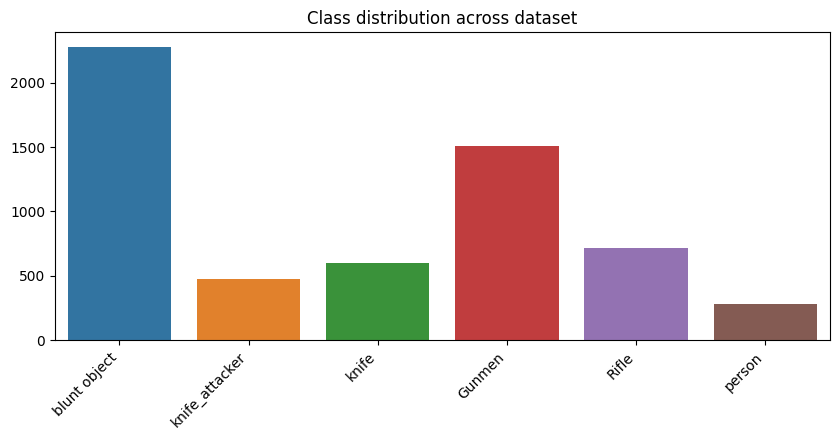

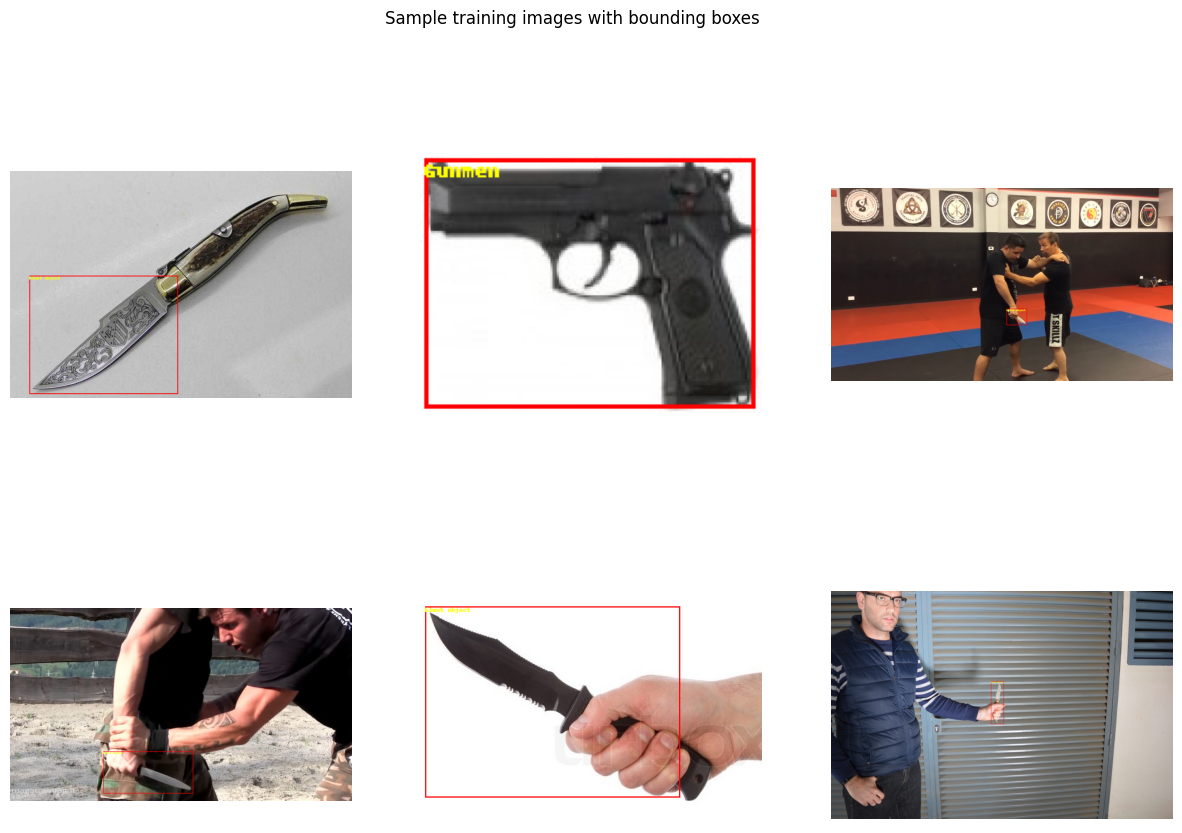

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns
import random
from PIL import Image, ImageDraw

# We are plotting class distribution
all_counts = collections.Counter()
for split in ["train","val","test"]:
    _, _, cc = count_split(Path(Y[split]))
    for k,v in cc.items():
        all_counts[CLASS_NAMES[k]] += v

plt.figure(figsize=(10,4))
sns.barplot(x=list(all_counts.keys()), y=list(all_counts.values()))
plt.xticks(rotation=45, ha="right")
plt.title("Class distribution across dataset")
plt.show()

# We are visualizing sample images with bounding boxes
def draw_boxes(img_path, labels_path):
    img = Image.open(img_path).convert("RGB")
    W,H = img.size
    draw = ImageDraw.Draw(img)
    if Path(labels_path).exists():
        for line in Path(labels_path).read_text().splitlines():
            parts = line.split()
            if len(parts) < 5: continue
            cid, xc,yc,w,h = map(float, parts)
            cid = int(cid)
            x0 = (xc - w/2) * W
            y0 = (yc - h/2) * H
            x1 = (xc + w/2) * W
            y1 = (yc + h/2) * H
            draw.rectangle([x0,y0,x1,y1], outline="red", width=2)
            draw.text((x0,y0), CLASS_NAMES[cid], fill="yellow")
    return img

sample_images = random.sample(
    glob.glob(str((data_root/"train"/"images").resolve()/"*.jpg")), 6
)

plt.figure(figsize=(15,10))
for i,imgp in enumerate(sample_images,1):
    lblp = (Path(imgp).parent.parent/"labels"/(Path(imgp).stem+".txt"))
    plt.subplot(2,3,i)
    plt.imshow(draw_boxes(imgp,lblp))
    plt.axis("off")
plt.suptitle("Sample training images with bounding boxes")
plt.show()

/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


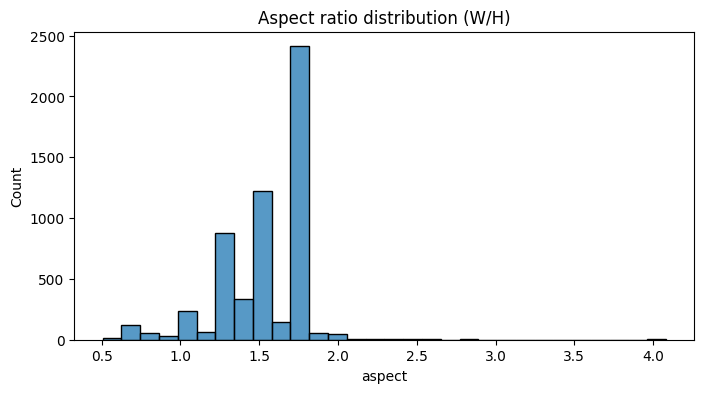

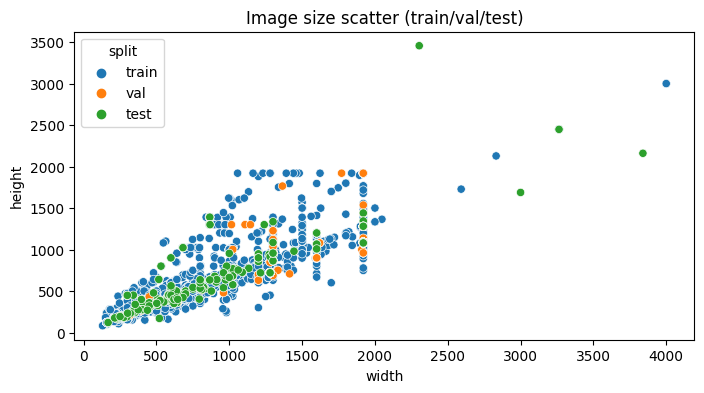

In [11]:
import pandas as pd

sizes = []
for split in ["train","val","test"]:
    imgs = glob.glob(str((Path(Y[split]))/"**/*.jpg"), recursive=True)
    for imgp in imgs:
        try:
            with Image.open(imgp) as im:
                w,h = im.size
                sizes.append({"split":split,"width":w,"height":h,"aspect":w/h})
        except: pass

df_sizes = pd.DataFrame(sizes)
plt.figure(figsize=(8,4))
sns.histplot(df_sizes["aspect"], bins=30, kde=False)
plt.title("Aspect ratio distribution (W/H)")
plt.show()

plt.figure(figsize=(8,4))
sns.scatterplot(data=df_sizes, x="width", y="height", hue="split")
plt.title("Image size scatter (train/val/test)")
plt.show()

/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


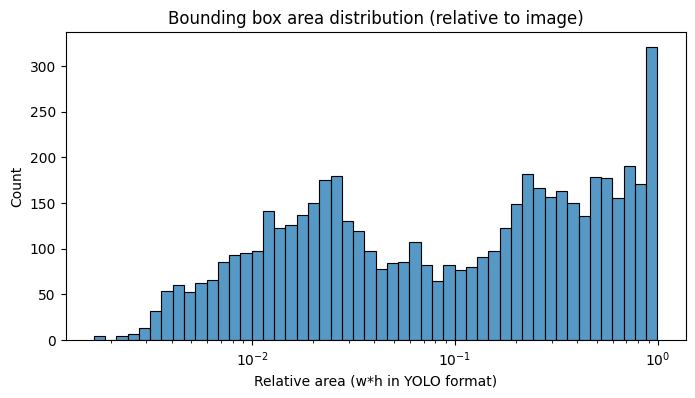

In [12]:
box_areas = []
for split in ["train","val"]:
    lbls = glob.glob(str((Path(Y[split]).parent/"labels")/"*.txt"))
    for lf in lbls:
        for line in Path(lf).read_text().splitlines():
            parts = line.split()
            if len(parts)<5: continue
            _, xc,yc,w,h = map(float, parts)
            box_areas.append(w*h)

plt.figure(figsize=(8,4))
sns.histplot(box_areas, bins=50, log_scale=True)
plt.title("Bounding box area distribution (relative to image)")
plt.xlabel("Relative area (w*h in YOLO format)")
plt.show()

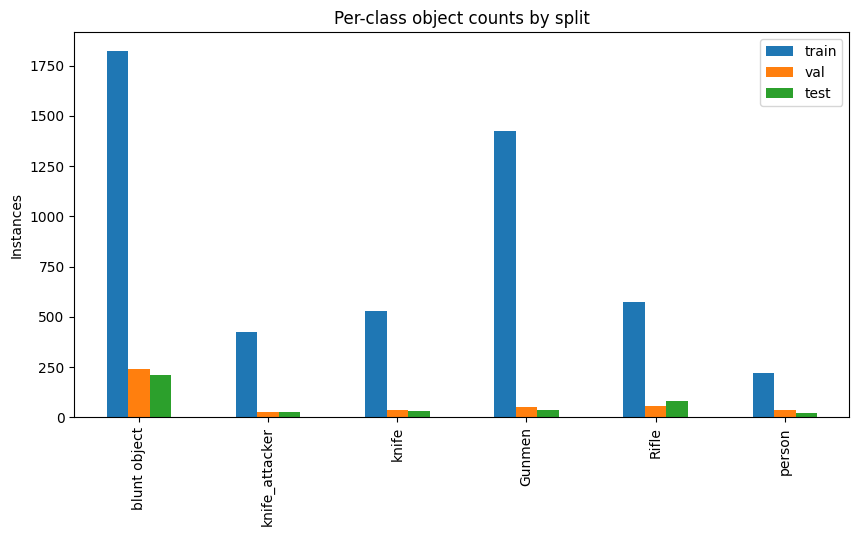

In [13]:
split_counts = {}
for split in ["train","val","test"]:
    _,_,cc = count_split(Path(Y[split]))
    split_counts[split] = {CLASS_NAMES[k]:v for k,v in cc.items()}

df_split = pd.DataFrame(split_counts).fillna(0).astype(int)
df_split.plot(kind="bar", figsize=(10,5))
plt.title("Per-class object counts by split")
plt.ylabel("Instances")
plt.show()

In [14]:
errors = []
for split in ["train","val","test"]:
    lbls = glob.glob(str((Path(Y[split]).parent/"labels")/"*.txt"))
    for lf in lbls:
        for line in Path(lf).read_text().splitlines():
            try:
                cid,xc,yc,w,h = map(float,line.split())
                if cid>=len(CLASS_NAMES) or xc<0 or yc<0 or w<=0 or h<=0 or xc>1 or yc>1:
                    errors.append((lf,line))
            except:
                errors.append((lf,line))
print("Potential label errors:", len(errors))
if errors:
    print(errors[:5])

Potential label errors: 0


In [15]:
save_period=1
project="/kaggle/working/runs_yolo"
name="yolov8_weapon_9class"
exist_ok=True

In [17]:
# STEP 4: training YOLOv8 and YOLOv11 (saving best.pt + exporting ONNX)

from ultralytics import YOLO
from pathlib import Path
import os

# we are setting training knobs (feel free to tweak)
EPOCHS   = int(os.environ.get("EPOCHS", 30))
IMG_SIZE = int(os.environ.get("IMG_SIZE", 640))
BATCH    = int(os.environ.get("BATCH", 16))
DEVICE   = int(os.environ.get("DEVICE", 0))   # -1 for CPU, 0 for first GPU
SEED     = 42

RUNS_DIR    = Path("/kaggle/working/runs"); RUNS_DIR.mkdir(parents=True, exist_ok=True)
REPORTS_DIR = Path("/kaggle/working/reports"); REPORTS_DIR.mkdir(parents=True, exist_ok=True)
PREDS_DIR   = Path("/kaggle/working/preds"); PREDS_DIR.mkdir(parents=True, exist_ok=True)

# we are picking compact weights for speed; switch to s/m/l/x for accuracy
YOLOV8_WEIGHTS  = os.environ.get("YOLOV8_WEIGHTS",  "yolov8n.pt")
YOLOV11_WEIGHTS = os.environ.get("YOLOV11_WEIGHTS", "yolov11s.pt")

print("we are training:", YOLOV8_WEIGHTS, "and", YOLOV11_WEIGHTS)

# we are training YOLOv8
y8 = YOLO(YOLOV8_WEIGHTS)
_ = y8.train(
    data=str(fixed_yaml),     
    epochs=EPOCHS,
    imgsz=IMG_SIZE,
    batch=BATCH,
    device=DEVICE,
    project=str(RUNS_DIR),
    name="yolov8_run",
    seed=SEED,
    patience=15,                # early stopping
    amp=True,                   # mixed precision if GPU
)

BEST_Y8 = RUNS_DIR / "detect" / "yolov8_run" / "weights" / "best.pt"
print("yolov8 best:", BEST_Y8, BEST_Y8.exists())
try:
    y8.export(format="onnx", opset=12, dynamic=True)
    print("yolov8 ONNX export is completing.")
except Exception as e:
    print("yolov8 ONNX export is failing:", e)

we are training: yolov8n.pt and yolov11s.pt
New https://pypi.org/project/ultralytics/8.3.181 available 😃 Update with 'pip install -U ultralytics'
Ultralytics YOLOv8.2.89 🚀 Python-3.10.13 torch-2.1.2 CUDA:0 (Tesla P100-PCIE-16GB, 16269MiB)
engine/trainer: task=detect, mode=train, model=yolov8n.pt, data=/kaggle/working/fixed_9class.yaml, epochs=30, time=None, patience=15, batch=16, imgsz=640, save=True, save_period=-1, cache=False, device=0, workers=8, project=/kaggle/working/runs, name=yolov8_run2, exist_ok=False, pretrained=True, optimizer=auto, verbose=True, seed=42, deterministic=True, single_cls=False, rect=False, cos_lr=False, close_mosaic=10, resume=False, amp=True, fraction=1.0, profile=False, freeze=None, multi_scale=False, overlap_mask=True, mask_ratio=4, dropout=0.0, val=True, split=val, save_json=False, save_hybrid=False, conf=None, iou=0.7, max_det=300, half=False, dnn=False, plots=True, source=None, vid_stride=1, stream_buffer=False, visualize=False, augment=False, agnostic

train: Scanning /kaggle/working/weapon-dataset/train/labels.cache... 5002 images, 0 backgrounds, 0 corrupt: 100%|██████████| 5002/5002 [00:00<?, ?it/s]

train: WARNING ⚠️ /kaggle/working/weapon-dataset/train/images/billete_2057.jpg: corrupt JPEG restored and saved
train: WARNING ⚠️ /kaggle/working/weapon-dataset/train/images/billete_2058.jpg: corrupt JPEG restored and saved
train: WARNING ⚠️ /kaggle/working/weapon-dataset/train/images/knife_71.jpg: corrupt JPEG restored and saved
train: WARNING ⚠️ /kaggle/working/weapon-dataset/train/images/monedero_1451.jpg: corrupt JPEG restored and saved
train: WARNING ⚠️ /kaggle/working/weapon-dataset/train/images/pistol_0583.jpg: corrupt JPEG restored and saved
train: WARNING ⚠️ /kaggle/working/weapon-dataset/train/images/pistol_1224.jpg: corrupt JPEG restored and saved
train: WARNING ⚠️ /kaggle/working/weapon-dataset/train/images/pistol_1717.jpg: corrupt JPEG restored and saved
train: WARNING ⚠️ /kaggle/working/weapon-dataset/train/images/pistol_2140.jpg: corrupt JPEG restored and saved
albumentations: Blur(p=0.01, blur_limit=(3, 7)), MedianBlur(p=0.01, blur_limit=(3, 7)), ToGray(p=0.01), CLAHE(p


val: Scanning /kaggle/working/weapon-dataset/val/labels.cache... 450 images, 0 backgrounds, 0 corrupt: 100%|██████████| 450/450 [00:00<?, ?it/s]


Plotting labels to /kaggle/working/runs/yolov8_run2/labels.jpg... 
optimizer: 'optimizer=auto' found, ignoring 'lr0=0.01' and 'momentum=0.937' and determining best 'optimizer', 'lr0' and 'momentum' automatically... 
optimizer: AdamW(lr=0.000769, momentum=0.9) with parameter groups 57 weight(decay=0.0), 64 weight(decay=0.0005), 63 bias(decay=0.0)
TensorBoard: model graph visualization added ✅
Image sizes 640 train, 640 val
Using 4 dataloader workers
Logging results to /kaggle/working/runs/yolov8_run2
Starting training for 30 epochs...

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size


...

                   all        450        450      0.801      0.823      0.863        0.7



30 epochs completed in 0.623 hours.
Optimizer stripped from /kaggle/working/runs/yolov8_run2/weights/last.pt, 6.2MB
Optimizer stripped from /kaggle/working/runs/yolov8_run2/weights/best.pt, 6.2MB

Validating /kaggle/working/runs/yolov8_run2/weights/best.pt...
Ultralytics YOLOv8.2.89 🚀 Python-3.10.13 torch-2.1.2 CUDA:0 (Tesla P100-PCIE-16GB, 16269MiB)
Model summary (fused): 168 layers, 3,007,403 parameters, 0 gradients, 8.1 GFLOPs


                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 15/15 [00:05<00:00,  2.92it/s]


                   all        450        450      0.856      0.797      0.869      0.708
                Gunmen         50         50      0.683       0.92      0.879      0.677
                 Rifle         58         58      0.961      0.844      0.956      0.815
          blunt object        241        241      0.947      0.963      0.985      0.689
                 knife         38         38      0.896      0.677      0.832      0.748
        knife_attacker         28         28      0.896      0.922      0.966      0.841
                person         35         35      0.755      0.457      0.593       0.48
Speed: 0.2ms preprocess, 1.4ms inference, 0.0ms loss, 2.3ms postprocess per image
Results saved to /kaggle/working/runs/yolov8_run2
yolov8 best: /kaggle/working/runs/detect/yolov8_run/weights/best.pt False
Ultralytics YOLOv8.2.89 🚀 Python-3.10.13 torch-2.1.2 CPU (Intel Xeon 2.00GHz)
Model summary (fused): 168 layers, 3,007,403 parameters, 0 gradients, 8.1 GFLOPs

PyTorch: st

FileNotFoundError: [Errno 2] No such file or directory: 'yolov11s.pt'

In [23]:
from pathlib import Path

cand_paths = [
    "/kaggle/working/runs/yolov8_run/weights/best.pt",
    "/kaggle/working/runs/yolov8_run2/weights/best.pt",
    "/kaggle/working/runs/detect/yolov8_run/weights/best.pt",
    "/kaggle/working/runs/detect/yolov8_run2/weights/best.pt",
]
candidates = [Path(p) for p in cand_paths if Path(p).exists()]

# also scan in case the name changed
candidates += sorted(Path("/kaggle/working/runs").rglob("weights/best.pt"))

# pick the newest one
assert candidates, "No yolov8 best.pt found — please run training first."
BEST_Y8 = sorted(set(candidates), key=lambda p: p.stat().st_mtime)[-1]
print("Using YOLOv8 best:", BEST_Y8)

Using YOLOv8 best: /kaggle/working/runs/yolov8_run2/weights/best.pt


In [24]:
from ultralytics import YOLO
fixed_yaml = "/kaggle/working/fixed_9class.yaml"  # your YAML from earlier

y8 = YOLO(str(BEST_Y8))
res8 = y8.val(data=fixed_yaml, imgsz=640, split="val")  # change to 'test' if you prefer

Ultralytics YOLOv8.2.89 🚀 Python-3.10.13 torch-2.1.2 CUDA:0 (Tesla P100-PCIE-16GB, 16269MiB)
Model summary (fused): 168 layers, 3,007,403 parameters, 0 gradients, 8.1 GFLOPs


val: Scanning /kaggle/working/weapon-dataset/val/labels.cache... 450 images, 0 backgrounds, 0 corrupt: 100%|██████████| 450/450 [00:00<?, ?it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 29/29 [00:06<00:00,  4.44it/s]


                   all        450        450      0.858      0.802      0.868      0.709
                Gunmen         50         50      0.692       0.92      0.878      0.678
                 Rifle         58         58      0.961      0.842      0.956      0.819
          blunt object        241        241      0.947      0.962      0.985      0.688
                 knife         38         38      0.895      0.676      0.832      0.746
        knife_attacker         28         28      0.899      0.956      0.967      0.847
                person         35         35      0.756      0.457      0.593      0.477
Speed: 0.1ms preprocess, 1.7ms inference, 0.0ms loss, 1.2ms postprocess per image
Results saved to runs/detect/val3


In [26]:
# we are upgrading ultralytics to a YOLOv11-capable version and restarting the kernel
import sys, subprocess
try:
    import ultralytics
    cur = ultralytics.__version__
except Exception:
    cur = "none"

print("current ultralytics:", cur)
subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "ultralytics>=8.3.1"])

# we are restarting the kernel so the new version is taking effect
import IPython
app = IPython.Application.instance()
app.kernel.do_shutdown(restart=True)

current ultralytics: 8.2.89


{'status': 'ok', 'restart': True}

In [1]:
# we are training YOLOv11 (downloaded weights if online; YAML fallback if offline)
from ultralytics import YOLO, __version__
from pathlib import Path
import os

print("ultralytics:", __version__)

EPOCHS, IMG_SIZE, BATCH, DEVICE = 30, 640, 16, 0
RUNS_DIR = Path("/kaggle/working/runs"); RUNS_DIR.mkdir(parents=True, exist_ok=True)
fixed_yaml = "/kaggle/working/fixed_9class.yaml"   # <-- your dataset YAML

# we are trying pretrained weights first
try:
    y11 = YOLO("yolo11s.pt")            # requires internet to auto-download
    print("we are using pretrained weights: yolo11s.pt")
except Exception as e:
    print("we are falling back to architecture YAML (offline mode):", e)
    y11 = YOLO("yolo11s.yaml")          # trains from scratch if no .pt available

_ = y11.train(
    data=fixed_yaml,
    epochs=EPOCHS,
    imgsz=IMG_SIZE,
    batch=BATCH,
    device=DEVICE,
    project=str(RUNS_DIR),
    name="yolo11_run",
    seed=42,
    patience=15,
    amp=True,
)

# we are resolving the saved best.pt (works for both runs/ and runs/detect/ layouts)
BEST_Y11 = None
cands = [
    RUNS_DIR / "yolo11_run" / "weights" / "best.pt",
    RUNS_DIR / "detect" / "yolo11_run" / "weights" / "best.pt",
]
for c in cands:
    if c.exists():
        BEST_Y11 = c
        break

if BEST_Y11 is None:
    # last resort: scan for any best.pt inside yolo11_run
    found = list((RUNS_DIR).rglob("yolo11_run/weights/best.pt"))
    BEST_Y11 = found[-1] if found else None

print("YOLOv11 best:", BEST_Y11, BEST_Y11.exists() if BEST_Y11 else None)

# (optional) export
if BEST_Y11:
    try:
        y11.export(format="onnx", opset=12, dynamic=True)
        print("yolo11 ONNX export is completing.")
    except Exception as e:
        print("yolo11 ONNX export is failing:", e)


Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
ultralytics: 8.3.181


we are using pretrained weights: yolo11s.pt
Ultralytics 8.3.181 🚀 Python-3.10.13 torch-2.1.2 CUDA:0 (Tesla P100-PCIE-16GB, 16269MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/working/fixed_9class.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=30, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11s.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=yolo11_run, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patienc

2025-08-19 14:44:24,324	INFO util.py:124 -- Outdated packages:
  ipywidgets==7.7.1 found, needs ipywidgets>=8
Run `pip install -U ipywidgets`, then restart the notebook server for rich notebook output.
2025-08-19 14:44:25,058	INFO util.py:124 -- Outdated packages:
  ipywidgets==7.7.1 found, needs ipywidgets>=8
Run `pip install -U ipywidgets`, then restart the notebook server for rich notebook output.


Overriding model.yaml nc=80 with nc=9

                   from  n    params  module                                       arguments                     
  0                  -1  1       928  ultralytics.nn.modules.conv.Conv             [3, 32, 3, 2]                 
  1                  -1  1     18560  ultralytics.nn.modules.conv.Conv             [32, 64, 3, 2]                
  2                  -1  1     26080  ultralytics.nn.modules.block.C3k2            [64, 128, 1, False, 0.25]     
  3                  -1  1    147712  ultralytics.nn.modules.conv.Conv             [128, 128, 3, 2]              
  4                  -1  1    103360  ultralytics.nn.modules.block.C3k2            [128, 256, 1, False, 0.25]    
  5                  -1  1    590336  ultralytics.nn.modules.conv.Conv             [256, 256, 3, 2]              
  6                  -1  1    346112  ultralytics.nn.modules.block.C3k2            [256, 256, 1, True]           
  7                  -1  1   1180672  ultralytics

AMP: checks passed ✅
train: Fast image access ✅ (ping: 0.0±0.0 ms, read: 2367.7±1260.6 MB/s, size: 179.9 KB)


...

      30/30      4.82G     0.5081     0.3286     0.9408         10        640: 100%|██████████| 313/313 [01:41<00:00,  3.08it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 15/15 [00:04<00:00,  3.65it/s]

                   all        450        450      0.852      0.842      0.903      0.746



30 epochs completed in 0.894 hours.
Optimizer stripped from /kaggle/working/runs/yolo11_run/weights/last.pt, 19.2MB
Optimizer stripped from /kaggle/working/runs/yolo11_run/weights/best.pt, 19.2MB

Validating /kaggle/working/runs/yolo11_run/weights/best.pt...
Ultralytics 8.3.181 🚀 Python-3.10.13 torch-2.1.2 CUDA:0 (Tesla P100-PCIE-16GB, 16269MiB)
YOLO11s summary (fused): 100 layers, 9,416,283 parameters, 0 gradients, 21.3 GFLOPs


                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 15/15 [00:05<00:00,  2.88it/s]


                   all        450        450      0.851      0.841      0.903      0.746
                Gunmen         50         50      0.783       0.94      0.917      0.669
                 Rifle         58         58      0.874       0.81       0.91      0.833
          blunt object        241        241      0.963      0.971      0.989      0.714
                 knife         38         38      0.835      0.816      0.881       0.74
        knife_attacker         28         28      0.842      0.893      0.958      0.888
                person         35         35      0.812      0.617      0.763      0.628
Speed: 0.1ms preprocess, 3.1ms inference, 0.0ms loss, 3.5ms postprocess per image
Results saved to /kaggle/working/runs/yolo11_run
YOLOv11 best: /kaggle/working/runs/yolo11_run/weights/best.pt True
Ultralytics 8.3.181 🚀 Python-3.10.13 torch-2.1.2 CPU (Intel Xeon 2.00GHz)
💡 ProTip: Export to OpenVINO format for best performance on Intel hardware. Learn more at https://docs.ul

In [2]:
# === 1) finding best.pt for both models ===
from pathlib import Path

RUNS = Path("/kaggle/working/runs")
# YOLOv8 from your two runs
y8_candidates = [
    RUNS / "yolov8_run"  / "weights" / "best.pt",
    RUNS / "yolov8_run2" / "weights" / "best.pt",
    RUNS / "detect" / "yolov8_run"  / "weights" / "best.pt",
    RUNS / "detect" / "yolov8_run2" / "weights" / "best.pt",
]
y8_candidates += list(RUNS.rglob("yolov8*/weights/best.pt"))
y8_candidates = [p for p in y8_candidates if p.exists()]
assert y8_candidates, "Couldn't find YOLOv8 best.pt — check your run name."
BEST_Y8 = sorted(set(y8_candidates), key=lambda p: p.stat().st_mtime)[-1]

# YOLOv11 from this run
y11_candidates = [
    RUNS / "yolo11_run"  / "weights" / "best.pt",
    RUNS / "detect" / "yolo11_run" / "weights" / "best.pt",
]
y11_candidates += list(RUNS.rglob("yolo11*/weights/best.pt"))
y11_candidates = [p for p in y11_candidates if p.exists()]
assert y11_candidates, "Couldn't find YOLOv11 best.pt — wait for training to finish."
BEST_Y11 = sorted(set(y11_candidates), key=lambda p: p.stat().st_mtime)[-1]

print("YOLOv8 best:", BEST_Y8)
print("YOLOv11 best:", BEST_Y11)

YOLOv8 best: /kaggle/working/runs/yolov8_run2/weights/best.pt
YOLOv11 best: /kaggle/working/runs/yolo11_run/weights/best.pt


In [3]:
# === 2) validating both models and saving metrics ===
from ultralytics import YOLO
import yaml, json
from pathlib import Path

fixed_yaml = "/kaggle/working/fixed_9class.yaml"
with open(fixed_yaml, "r") as f:
    cfg = yaml.safe_load(f)
split = "val" if cfg.get("val") else ("test" if cfg.get("test") else "train")
print("Evaluating on:", split)

REPORTS = Path("/kaggle/working/reports"); REPORTS.mkdir(parents=True, exist_ok=True)
results_all = {}

r8  = YOLO(str(BEST_Y8)).val (data=fixed_yaml, split=split, imgsz=640, conf=0.25, save_json=True)
r11 = YOLO(str(BEST_Y11)).val(data=fixed_yaml, split=split, imgsz=640, conf=0.25, save_json=True)

results_all["YOLOv8"]  = {"metrics": getattr(r8,  "results_dict", {}), "speed": getattr(r8,  "speed", None)}
results_all["YOLOv11"] = {"metrics": getattr(r11, "results_dict", {}), "speed": getattr(r11, "speed", None)}

(REPORTS/"metrics_summary.json").write_text(json.dumps(results_all, indent=2))
print("Saved metrics to:", REPORTS/"metrics_summary.json")

Evaluating on: val
Ultralytics 8.3.181 🚀 Python-3.10.13 torch-2.1.2 CUDA:0 (Tesla P100-PCIE-16GB, 16269MiB)
Model summary (fused): 72 layers, 3,007,403 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 4040.2±788.1 MB/s, size: 277.3 KB)


val: Scanning /kaggle/working/weapon-dataset/val/labels.cache... 450 images, 0 backgrounds, 0 corrupt: 100%|██████████| 450/450 [00:00<?, ?it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 29/29 [00:06<00:00,  4.34it/s]


                   all        450        450      0.858      0.802      0.866       0.73
                Gunmen         50         50      0.692       0.92      0.879      0.691
                 Rifle         58         58      0.961      0.842      0.945       0.83
          blunt object        241        241      0.947      0.962      0.978      0.707
                 knife         38         38      0.895      0.676      0.824      0.755
        knife_attacker         28         28      0.899      0.956      0.961      0.865
                person         35         35      0.756      0.457      0.609      0.534
Speed: 0.6ms preprocess, 2.6ms inference, 0.0ms loss, 3.3ms postprocess per image
Saving runs/detect/val4/predictions.json...
Results saved to runs/detect/val4
Ultralytics 8.3.181 🚀 Python-3.10.13 torch-2.1.2 CUDA:0 (Tesla P100-PCIE-16GB, 16269MiB)
YOLO11s summary (fused): 100 layers, 9,416,283 parameters, 0 gradients, 21.3 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, 

val: Scanning /kaggle/working/weapon-dataset/val/labels.cache... 450 images, 0 backgrounds, 0 corrupt: 100%|██████████| 450/450 [00:00<?, ?it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 29/29 [00:07<00:00,  4.11it/s]


                   all        450        450      0.854      0.843      0.892      0.754
                Gunmen         50         50      0.785       0.94      0.905      0.669
                 Rifle         58         58      0.877       0.81      0.903      0.844
          blunt object        241        241      0.963      0.969      0.987      0.734
                 knife         38         38      0.837      0.811      0.865      0.753
        knife_attacker         28         28      0.853      0.929      0.942      0.894
                person         35         35      0.808      0.602      0.751      0.631
Speed: 0.5ms preprocess, 5.7ms inference, 0.0ms loss, 2.0ms postprocess per image
Saving runs/detect/val5/predictions.json...
Results saved to runs/detect/val5
Saved metrics to: /kaggle/working/reports/metrics_summary.json


,model,mAP50-95,mAP50,precision,recall,val_time_ms/img
1,YOLOv11,0.754077,0.892149,0.853907,0.843427,5.702205
0,YOLOv8,0.730335,0.865873,0.858375,0.802275,2.594859


Saved: /kaggle/working/reports/comparison.csv


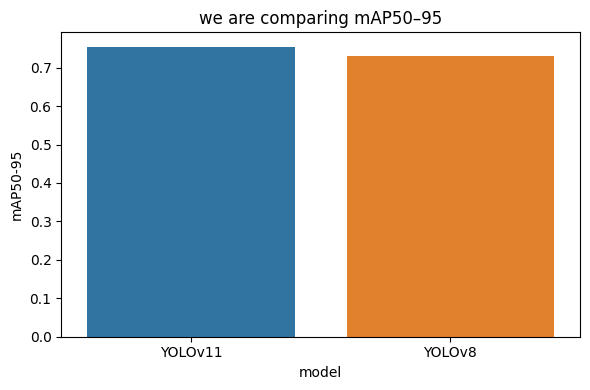

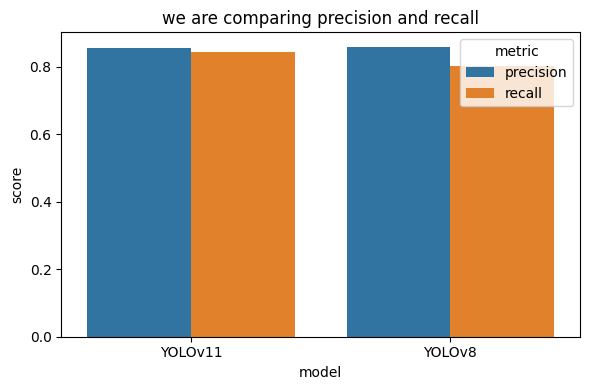

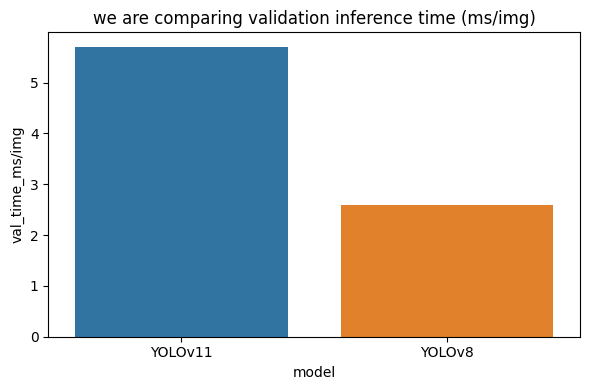

In [6]:
# Robust comparison table + plots (handles speed as dict OR float)
from pathlib import Path
import json, pandas as pd, numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

REPORTS = Path("/kaggle/working/reports")
summary = json.loads((REPORTS / "metrics_summary.json").read_text())

def pick(d: dict, keys, default=None):
    """Return the first existing key from keys in dict d."""
    if not isinstance(d, dict):
        return default
    for k in keys:
        if k in d:
            return d[k]
    return default

def speed_value(sp):
    """Normalize speed field to a single float (ms/img) if possible."""
    # sp may be a float, dict, or None depending on ultralytics version
    if isinstance(sp, (int, float)):
        return float(sp)
    if isinstance(sp, dict):
        inf = sp.get("inference")
        if isinstance(inf, dict):
            # common keys
            return inf.get("average") or inf.get("mean") or next(
                (v for v in inf.values() if isinstance(v, (int, float))), None
            )
        if isinstance(inf, (int, float)):
            return float(inf)
        # try common fallbacks on the dict itself
        for k in ("avg", "average", "mean"):
            if k in sp and isinstance(sp[k], (int, float)):
                return float(sp[k])
        # last resort: any numeric value in dict
        for v in sp.values():
            if isinstance(v, (int, float)):
                return float(v)
    return None

rows = []
for name, payload in summary.items():
    m = payload.get("metrics", {}) or {}
    sp = payload.get("speed", None)

    rows.append({
        "model": name,
        "mAP50-95": pick(m, ["metrics/mAP50-95(B)", "metrics/mAP50-95", "box/mAP50-95", "map50-95"]),
        "mAP50":    pick(m, ["metrics/mAP50(B)",    "metrics/mAP50",    "box/mAP50",    "map50"]),
        "precision":pick(m, ["metrics/precision(B)","metrics/precision","precision"]),
        "recall":   pick(m, ["metrics/recall(B)",   "metrics/recall",   "recall"]),
        "val_time_ms/img": speed_value(sp),
    })

df = pd.DataFrame(rows)

# ensure numeric
for c in ["mAP50-95", "mAP50", "precision", "recall", "val_time_ms/img"]:
    if c in df.columns:
        df[c] = pd.to_numeric(df[c], errors="coerce")

df = df.sort_values("mAP50-95", ascending=False)
display(df)

df.to_csv(REPORTS / "comparison.csv", index=False)
print("Saved:", REPORTS / "comparison.csv")

# Plots
plt.figure(figsize=(6,4))
sns.barplot(data=df, x="model", y="mAP50-95")
plt.title("we are comparing mAP50–95")
plt.tight_layout(); plt.show()

plt.figure(figsize=(6,4))
sns.barplot(
    data=df.melt(id_vars="model", value_vars=["precision","recall"], var_name="metric", value_name="score"),
    x="model", y="score", hue="metric"
)
plt.title("we are comparing precision and recall")
plt.tight_layout(); plt.show()

if "val_time_ms/img" in df and df["val_time_ms/img"].notna().any():
    plt.figure(figsize=(6,4))
    sns.barplot(data=df, x="model", y="val_time_ms/img")
    plt.title("we are comparing validation inference time (ms/img)")
    plt.tight_layout(); plt.show()

In [7]:
# we are generating plots (confusion matrix, PR/F1 curves) into fixed folders
from ultralytics import YOLO
from pathlib import Path
import yaml

fixed_yaml = "/kaggle/working/fixed_9class.yaml"
with open(fixed_yaml, "r") as f:
    cfg = yaml.safe_load(f)
split = "val" if cfg.get("val") else ("test" if cfg.get("test") else "train")

# we are locating best weights for both models
RUNS = Path("/kaggle/working/runs")
def latest_best(pattern):
    cands = sorted(RUNS.rglob(pattern))
    return cands[-1] if cands else None

BEST_Y8  = latest_best("yolov8*/weights/best.pt")
BEST_Y11 = latest_best("yolo11*/weights/best.pt") or latest_best("yolov11*/weights/best.pt")
print("yolov8 best:", BEST_Y8)
print("yolo11 best:", BEST_Y11)

# folders to store plots
VAL_ROOT = RUNS / "valplots"
out8  = VAL_ROOT / "yolov8";  out8.mkdir(parents=True, exist_ok=True)
out11 = VAL_ROOT / "yolo11";  out11.mkdir(parents=True, exist_ok=True)

# we are running lightweight val to generate plots
_ = YOLO(str(BEST_Y8)).val (data=fixed_yaml, split=split, imgsz=640, conf=0.25, plots=True,
                            project=str(VAL_ROOT), name="yolov8", save_json=False, verbose=False)
_ = YOLO(str(BEST_Y11)).val(data=fixed_yaml, split=split, imgsz=640, conf=0.25, plots=True,
                            project=str(VAL_ROOT), name="yolo11", save_json=False, verbose=False)
print("we are saving plots to:", out8, "and", out11)

yolov8 best: /kaggle/working/runs/yolov8_run2/weights/best.pt
yolo11 best: /kaggle/working/runs/yolo11_run/weights/best.pt
Ultralytics 8.3.181 🚀 Python-3.10.13 torch-2.1.2 CUDA:0 (Tesla P100-PCIE-16GB, 16269MiB)
Model summary (fused): 72 layers, 3,007,403 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 3440.5±965.5 MB/s, size: 333.5 KB)


val: Scanning /kaggle/working/weapon-dataset/val/labels.cache... 450 images, 0 backgrounds, 0 corrupt: 100%|██████████| 450/450 [00:00<?, ?it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 29/29 [00:06<00:00,  4.38it/s]


                   all        450        450      0.858      0.802      0.866       0.73
Speed: 0.5ms preprocess, 2.6ms inference, 0.0ms loss, 2.4ms postprocess per image
Results saved to /kaggle/working/runs/valplots/yolov82
Ultralytics 8.3.181 🚀 Python-3.10.13 torch-2.1.2 CUDA:0 (Tesla P100-PCIE-16GB, 16269MiB)
YOLO11s summary (fused): 100 layers, 9,416,283 parameters, 0 gradients, 21.3 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 2870.3±1143.4 MB/s, size: 434.1 KB)


val: Scanning /kaggle/working/weapon-dataset/val/labels.cache... 450 images, 0 backgrounds, 0 corrupt: 100%|██████████| 450/450 [00:00<?, ?it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 29/29 [00:06<00:00,  4.25it/s]


                   all        450        450      0.854      0.843      0.892      0.754
Speed: 0.6ms preprocess, 4.2ms inference, 0.0ms loss, 2.5ms postprocess per image
Results saved to /kaggle/working/runs/valplots/yolo112
we are saving plots to: /kaggle/working/runs/valplots/yolov8 and /kaggle/working/runs/valplots/yolo11


we are using 6 sample images for visualization
Results saved to /kaggle/working/preds/yolov83
Results saved to /kaggle/working/preds/yolo113


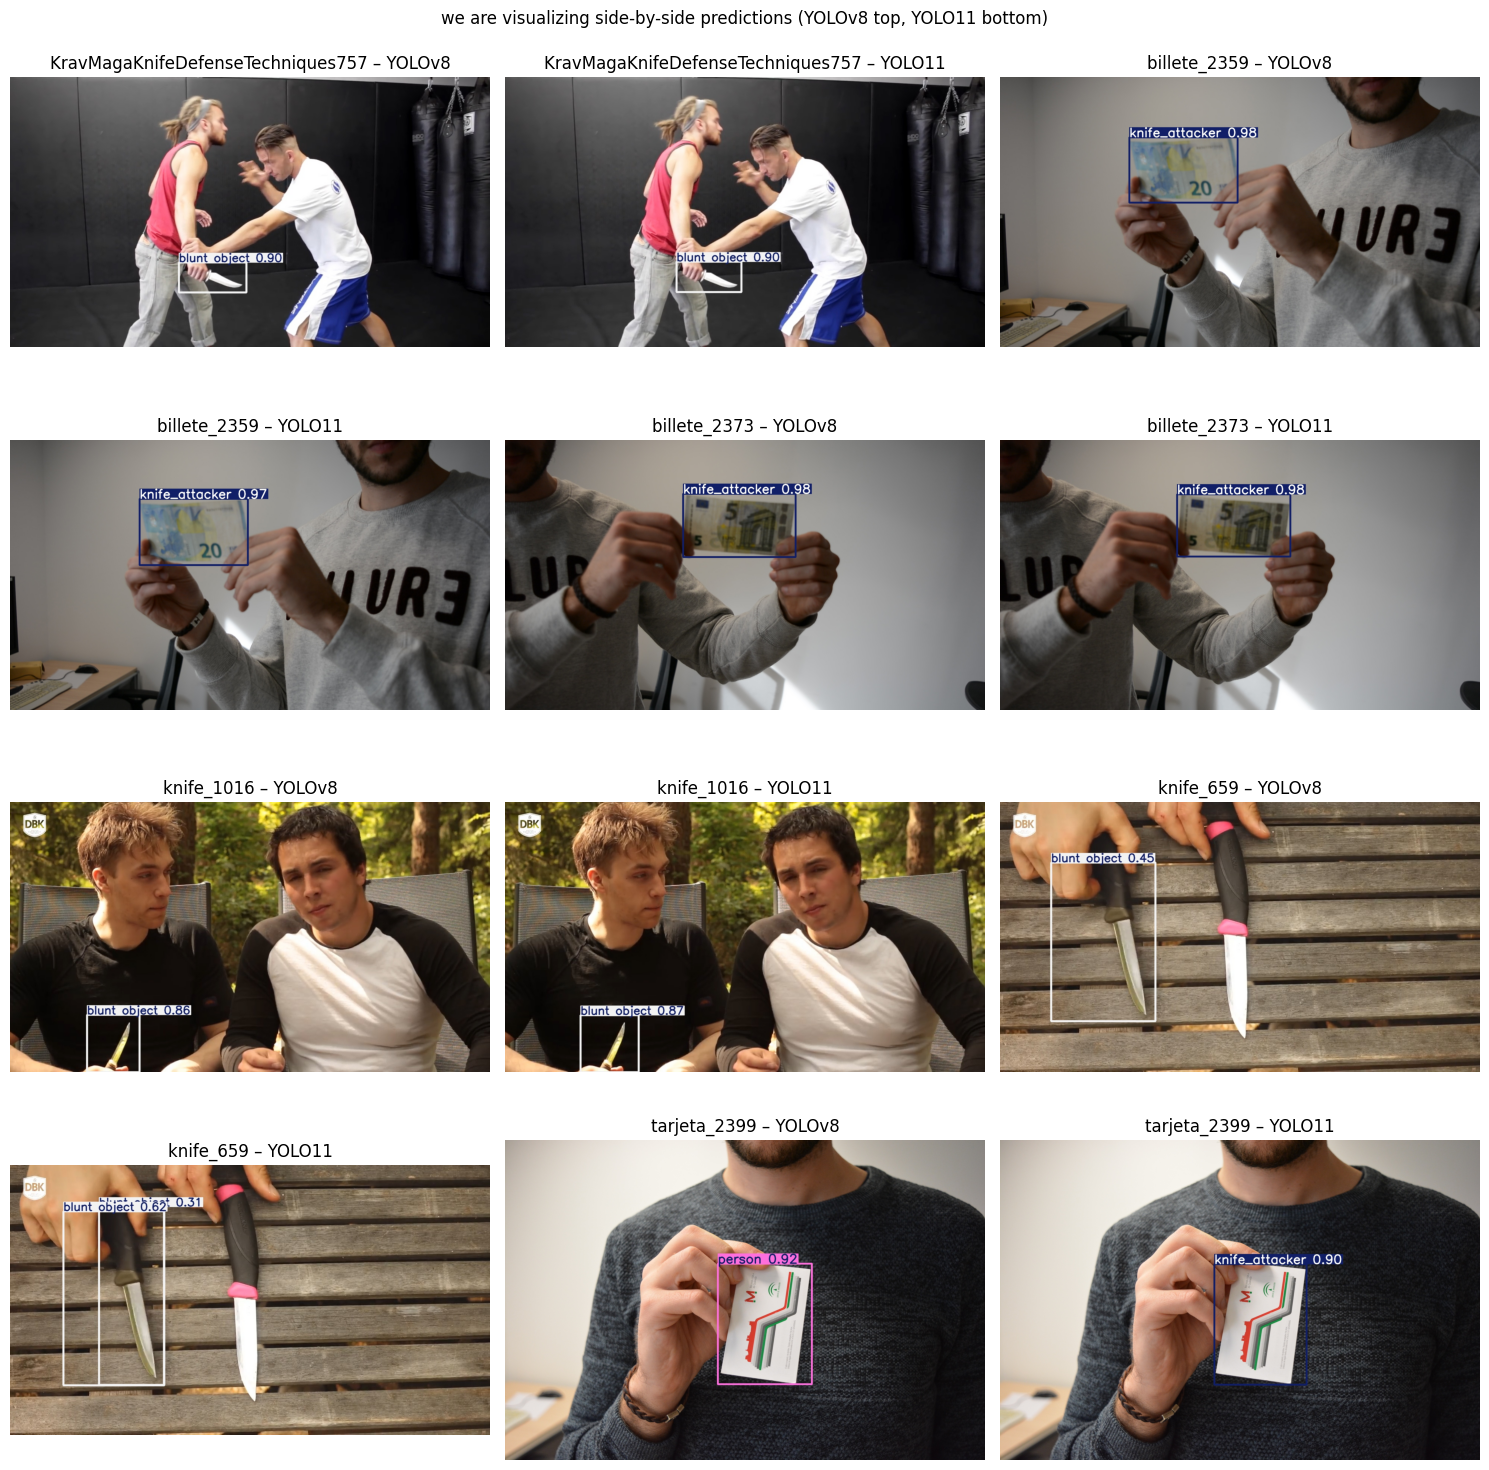

In [11]:
# we are rendering predictions side-by-side for both models
from ultralytics import YOLO
from glob import glob
import random, numpy as np
from PIL import Image
import matplotlib.pyplot as plt
from pathlib import Path

PREDS = Path("/kaggle/working/preds"); PREDS.mkdir(parents=True, exist_ok=True)

val_dir = cfg.get("val") or cfg.get("test") or cfg.get("train")
exts = ("*.jpg","*.jpeg","*.png","*.bmp","*.webp","*.JPG","*.PNG","*.JPEG")
pool=[]; [pool.extend(glob(str(Path(val_dir)/"**"/e), recursive=True)) for e in exts]
random.shuffle(pool); samples = pool[:6]
print("we are using", len(samples), "sample images for visualization")

def predict_to_dir(weight, name):
    out = PREDS / name
    YOLO(str(weight)).predict(samples, conf=0.25, imgsz=640, device=0, save=True,
                              project=str(PREDS), name=name, verbose=False)
    return out

out8  = predict_to_dir(BEST_Y8,  "yolov8")
out11 = predict_to_dir(BEST_Y11, "yolo11")

# we are showing a 2xN grid: top=YOLOv8, bottom=YOLO11 for the same files (matching by basename)
def render_grid(a_dir, b_dir, max_n=6):
    a_imgs = {p.stem:p for p in sorted(list(Path(a_dir).glob("*.*")))}
    b_imgs = {p.stem:p for p in sorted(list(Path(b_dir).glob("*.*")))}
    common = [k for k in a_imgs.keys() if k in b_imgs][:max_n]
    if not common:
        print("no common rendered files to display")
        return
    cols = min(3, len(common))
    rows = 2 * int(np.ceil(len(common)/cols))
    plt.figure(figsize=(5*cols, 3.8*rows))
    idx=1
    for k in common:
        plt.subplot(rows, cols, idx);   plt.imshow(Image.open(a_imgs[k])); plt.axis("off"); plt.title(f"{k} – YOLOv8"); idx+=1
        plt.subplot(rows, cols, idx);   plt.imshow(Image.open(b_imgs[k])); plt.axis("off"); plt.title(f"{k} – YOLO11"); idx+=1
    plt.suptitle("we are visualizing side-by-side predictions (YOLOv8 top, YOLO11 bottom)")
    plt.tight_layout(); plt.show()

render_grid(out8, out11, max_n=6)

Ultralytics 8.3.181 🚀 Python-3.10.13 torch-2.1.2 CUDA:0 (Tesla P100-PCIE-16GB, 16269MiB)
Model summary (fused): 72 layers, 3,007,403 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 2996.8±794.4 MB/s, size: 216.2 KB)


val: Scanning /kaggle/working/weapon-dataset/val/labels.cache... 450 images, 0 backgrounds, 0 corrupt: 100%|██████████| 450/450 [00:00<?, ?it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 29/29 [00:06<00:00,  4.42it/s]


                   all        450        450      0.535      0.513       0.54      0.414
                Gunmen         50         50      0.667       0.32      0.512      0.414
                 Rifle         58         58      0.765      0.448       0.64      0.533
          blunt object        241        241      0.669      0.705      0.734      0.407
                 knife         38         38      0.238      0.632      0.332      0.278
        knife_attacker         28         28      0.585      0.857      0.804       0.65
                person         35         35      0.286      0.114      0.217      0.204
Speed: 0.6ms preprocess, 1.6ms inference, 0.0ms loss, 1.3ms postprocess per image
Saving runs/detect/val6/predictions.json...
Results saved to runs/detect/val6
Ultralytics 8.3.181 🚀 Python-3.10.13 torch-2.1.2 CUDA:0 (Tesla P100-PCIE-16GB, 16269MiB)
Model summary (fused): 72 layers, 3,007,403 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read

val: Scanning /kaggle/working/weapon-dataset/val/labels.cache... 450 images, 0 backgrounds, 0 corrupt: 100%|██████████| 450/450 [00:00<?, ?it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 29/29 [00:06<00:00,  4.22it/s]


                   all        450        450      0.858      0.802      0.866       0.73
                Gunmen         50         50      0.692       0.92      0.879      0.691
                 Rifle         58         58      0.961      0.842      0.945       0.83
          blunt object        241        241      0.947      0.962      0.978      0.707
                 knife         38         38      0.895      0.676      0.824      0.755
        knife_attacker         28         28      0.899      0.956      0.961      0.865
                person         35         35      0.756      0.457      0.609      0.534
Speed: 0.5ms preprocess, 2.6ms inference, 0.0ms loss, 1.4ms postprocess per image
Saving runs/detect/val7/predictions.json...
Results saved to runs/detect/val7


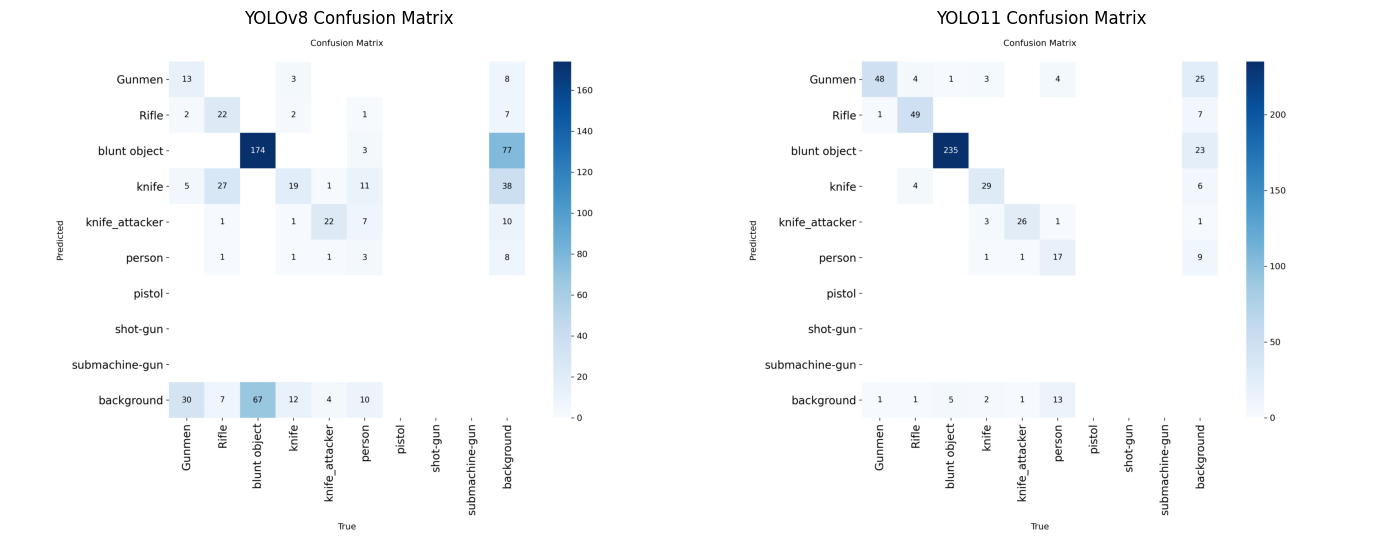

In [14]:
from ultralytics import YOLO
import matplotlib.pyplot as plt
from PIL import Image
from pathlib import Path

# locate best weights (adjust if different)
BEST_Y8  = Path("/kaggle/working/runs/yolov8_run/weights/best.pt")
BEST_Y11 = Path("/kaggle/working/runs/yolov8_run2/weights/best.pt")  # adjust if you trained YOLO11 elsewhere

# validate both with confusion matrix saving
m8  = YOLO(str(BEST_Y8))
m11 = YOLO(str(BEST_Y11))

res8  = m8.val(split="val", conf=0.25, save_json=True, save_conf=True, plots=True, imgsz=640)
res11 = m11.val(split="val", conf=0.25, save_json=True, save_conf=True, plots=True, imgsz=640)

# locate confusion matrix images
cm8  = Path(res8.save_dir) / "confusion_matrix.png"
cm11 = Path(res11.save_dir) / "confusion_matrix.png"

# display side by side
fig, axs = plt.subplots(1, 2, figsize=(14,6))
for ax, imgp, title in zip(axs, [cm8, cm11], ["YOLOv8 Confusion Matrix", "YOLO11 Confusion Matrix"]):
    if imgp.exists():
        ax.imshow(Image.open(imgp))
        ax.set_title(title)
        ax.axis("off")
    else:
        ax.text(0.5, 0.5, "confusion_matrix.png not found", ha="center", va="center")
plt.tight_layout()
plt.show()
